# Tracks-Only Pipeline — **UMAP → HDBSCAN → Random Forest** (Macrophages)

Analyzes **macrophages only** (9 replicates), entirely separate from the B cell analysis
(`..._BCells.ipynb`) — no B cell data is mixed in at any stage, not even at loading.

**Why kept separate:** evidence showed that pooling macrophages and B cells together (i)
doesn't cleanly separate by cell type, (ii) collapses real macrophage substructure into fewer
clusters than macrophages show on their own, and (iii) risked a z-score-normalization confound
from pooling two populations with very different feature variances.

Data for this run comes from `Final Analysis Data/Macrophages`, using a systematic
`{date}_{size}um_Macrophage_R{rep}.csv` naming convention where the replicate number is a
verified, consistent identifier across paired B-cell/macrophage files from the same experiment.

Each run of this notebook creates a new, dated output folder under
`Final Analysis Outputs/Macrophages Updated` (see Section 1b) so results from different runs
are never overwritten.

## Imports
All third-party and standard-library imports used by the pipeline.

In [1]:
# ─── IMPORTS ───────────────────────────────────────────────────────────────
import os
import re
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors

from scipy.sparse.csgraph import connected_components

import umap.umap_ as umap
import hdbscan
import shap

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

import plotly.express as px
import plotly.io as pio
from plotly.offline import init_notebook_mode

pio.renderers.default = "notebook"
init_notebook_mode(connected=True)


## 1. Configuration
Path to the final-analysis macrophage data, movement features, UMAP/HDBSCAN/RF
hyperparameters, and the systematic-filename regex.

In [2]:
# ─── 1) CONFIG ────────────────────────────────────────────────────────────────

# All data/output paths are relative to this notebook's own folder, so the
# notebook is portable across machines -- just keep it alongside
# `Final Analysis Data/` and `Final Analysis Outputs/`.
BASE_DIR = Path.cwd()

# Directory containing MACROPHAGE TRACKS CSVs for the final analysis.
MACRO_TRACKS_DIR = BASE_DIR / "Final Analysis Data" / "Macrophages"

# ─── Replicate selection ──────────────────────────────────────────────────────
# A data folder can hold MORE files than should actually be used in the analysis
# (e.g. keeping an old/alternate replicate around for later comparison without
# deleting it). List dates here to skip them at load time -- date is used as
# the key since it's the only reliable identifier in this dataset (replicate
# numbers baked into filenames have not always been consistent).
#
# To swap which replicate is used for a given size, just add the date you
# don't want to the exclude list below -- no need to move or delete any files.
MACRO_EXCLUDE_DATES = ["20240703"]  # 60um: keeping R1 in the folder, using R2 (20240917) instead (reverted)

# Track-level features to use (removed: "NUMBER_GAPS")
FEATURES = [
     "NUMBER_SPOTS","NUMBER_SPLITS","TRACK_DURATION","TRACK_DISPLACEMENT",
    "TRACK_MEDIAN_SPEED","TOTAL_DISTANCE_TRAVELED","MEAN_DIRECTIONAL_CHANGE_RATE",
    "CONFINEMENT_RATIO"
]

# Macrophages showed too many small clusters under the B cell defaults; these
# looser/coarser settings (wider UMAP neighborhood, larger min_dist, larger
# min_cluster_size) are used for the macrophage clustering run.
UMAP_PARAMS_MACRO = dict(
    n_neighbors=40,
    min_dist=0.3,
    n_components=2,
    metric="euclidean",
    random_state=42
)

HDBSCAN_PARAMS_MACRO = dict(
    min_cluster_size=75,
    min_samples=10,
    cluster_selection_method="eom"
)

RF_PARAMS = dict(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Filename parsing for the systematic naming convention created for this final analysis:
#   {date}_{size}um_Macrophage_R{rep}.csv       e.g. 20240508_60um_Macrophage_R4.csv
MACRO_REGEX = re.compile(r"(?P<size>30|60|90)um_Macrophage_R(?P<rep>\d+)", re.IGNORECASE)

# Base output folder for RF/SHAP figures -- a fresh dated run folder is created
# inside this in Section 1b, so outputs from different runs never collide.
MACRO_OUTDIR_BASE = BASE_DIR / "Final Analysis Outputs" / "Macrophages Updated"


## 1b. Output folder for this run
Creates a new folder for this run's outputs, named by today's date (e.g. `20260728`).
If this notebook is run again on the same date, later runs get `_trial2`, `_trial3`, etc.
appended so nothing gets overwritten.

In [3]:
# ─── 1b) OUTPUT FOLDER FOR THIS RUN ──────────────────────────────────────────
def make_run_dir(base_dir: Path) -> Path:
    """Create a new output folder for this run, named by today's date.
    First run of the day:      base_dir/YYYYMMDD
    Subsequent runs same day:  base_dir/YYYYMMDD_trial2, _trial3, ...
    """
    today = date.today().strftime("%Y%m%d")
    run_dir = base_dir / today
    if not run_dir.exists():
        run_dir.mkdir(parents=True)
        return run_dir
    trial = 2
    while True:
        candidate = base_dir / f"{today}_trial{trial}"
        if not candidate.exists():
            candidate.mkdir(parents=True)
            return candidate
        trial += 1

MACRO_OUTDIR = make_run_dir(MACRO_OUTDIR_BASE)
print(f"[OK] This run's outputs will be saved to: ./{MACRO_OUTDIR.relative_to(BASE_DIR)}")


[OK] This run's outputs will be saved to: ./Final Analysis Outputs/Macrophages Updated/20260813


## 2. Environment check
Prints the active Python version (sanity check only).

In [4]:
from platform import python_version
print(python_version())


3.13.5


## 3. Helper functions
Parse condition metadata from the systematic filenames created for this final analysis.

In [5]:
# ─── 3) HELPERS ───────────────────────────────────────────────────────────────
def parse_macro_filename(fname: str):
    """Parse (size, rep) from the systematic macrophage filename convention."""
    m = MACRO_REGEX.search(os.path.basename(fname))
    if not m:
        return None, None
    return m.group("size"), m.group("rep")

DATE_RE = re.compile(r"(20\d{6})")

def parse_date(fname: str):
    """Extract the YYYYMMDD date prefix -- the only reliable identifier across
    this dataset's various naming conventions."""
    m = DATE_RE.search(os.path.basename(fname))
    return m.group(1) if m else None


## 4. Load macrophage data (analyzed separately)
Loads the 9 macrophage replicates into their own dataframe -- no B cell rows are ever mixed
in.

In [6]:
# ─── 4) LOAD MACROPHAGE DATA ─────────────────────────────────────────────────
macro_frames = []
macro_needs_map = []
macro_skipped_excluded = []
macro_files = sorted(MACRO_TRACKS_DIR.glob("*.csv"))
for p in macro_files:
    date_ = parse_date(p.name)
    if date_ in MACRO_EXCLUDE_DATES:
        macro_skipped_excluded.append(p.name)
        continue
    size, rep = parse_macro_filename(p.name)
    if not all([size, rep]):
        macro_needs_map.append(p.name)
        continue
    df_ = pd.read_csv(p)
    for _col in FEATURES:
        if _col in df_.columns:
            df_[_col] = pd.to_numeric(df_[_col], errors="coerce")
    df_["__size"] = size
    df_["__rep"] = rep
    df_["condition"] = f"{size}um"
    df_["source_file"] = p.name
    macro_frames.append(df_)

if macro_needs_map:
    print("[WARN] Could not parse these macrophage files:", macro_needs_map)
if macro_skipped_excluded:
    print("[INFO] Skipped (in MACRO_EXCLUDE_DATES):", macro_skipped_excluded)

assert len(macro_frames) > 0, "No readable/parsable macrophage CSVs."
raw_macro = pd.concat(macro_frames, ignore_index=True)
print(f"[OK] Loaded macrophages: {len(macro_frames)} files used (of {len(macro_files)} found) -> {len(raw_macro)} rows")
print("Conditions:", sorted(raw_macro["condition"].dropna().unique()))
print("Replicates:", sorted(raw_macro["__rep"].dropna().unique()))
print("\nPoints per size:")
print(raw_macro.groupby("__size").size())


[INFO] Skipped (in MACRO_EXCLUDE_DATES): ['20240703_60um_Macrophage_R1.csv']
[OK] Loaded macrophages: 9 files used (of 10 found) -> 13528 rows
Conditions: ['30um', '60um', '90um']
Replicates: ['1', '2', '3', '4', '5']

Points per size:
__size
30    7417
60    3713
90    2398
dtype: int64


## 5. Feature selection
Cleans the macrophage dataset, keeping only rows where all `FEATURES` are present and
finite.

In [7]:
# ─── 5) FEATURE SELECTION ────────────────────────────────────────────────────
feat_cols = [c for c in FEATURES if c in raw_macro.columns]
missing = [c for c in FEATURES if c not in feat_cols]
if missing:
    print("[WARN] Missing features (skipped):", missing)
assert len(feat_cols) >= 2, "Not enough target features present."

X_macro0 = raw_macro[feat_cols].replace([np.inf, -np.inf], np.nan).dropna()
df_macro = raw_macro.loc[X_macro0.index].copy()
X_macro = df_macro[feat_cols].copy()
print("[OK] Macrophages after cleanup:", X_macro.shape[0], "tracks,", len(feat_cols), "features")


[OK] Macrophages after cleanup: 13455 tracks, 8 features


## 6. UMAP assumption check (QC)
Runs the kNN-connectivity / local-density-smoothness QC on the macrophage dataset.

=== Macrophages UMAP QC ===


,source_file,__size,__mac,__rep,n_points,n_components,dominant_component_fraction,volume_cv
0,20240508_60um_Macrophage_R4.csv,60,None,4,1314,1,1.000000,2.601604
1,20240911_90um_Macrophage_R1.csv,90,None,1,850,1,1.000000,3.545252
2,20240917_60um_Macrophage_R2.csv,60,None,2,744,1,1.000000,3.702041
3,20240918_30um_Macrophage_R1.csv,30,None,1,1665,8,0.667868,2.685125
4,20240924_90um_Macrophage_R2.csv,90,None,2,555,1,1.000000,3.113073
5,20241002_30um_Macrophage_R3.csv,30,None,3,2753,16,0.447512,3.290047
6,20250618_30um_Macrophage_R4.csv,30,None,4,2990,18,0.342475,3.531630
7,20250624_90um_Macrophage_R5.csv,90,None,5,984,4,0.826220,3.011540
8,20250627_60um_Macrophage_R5.csv,60,None,5,1600,9,0.726875,2.887239


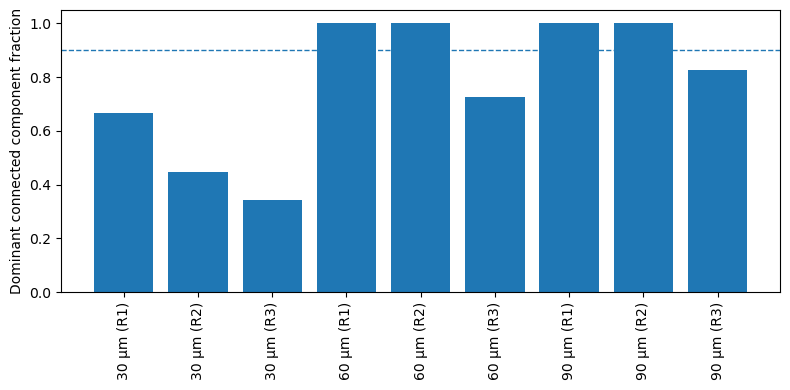

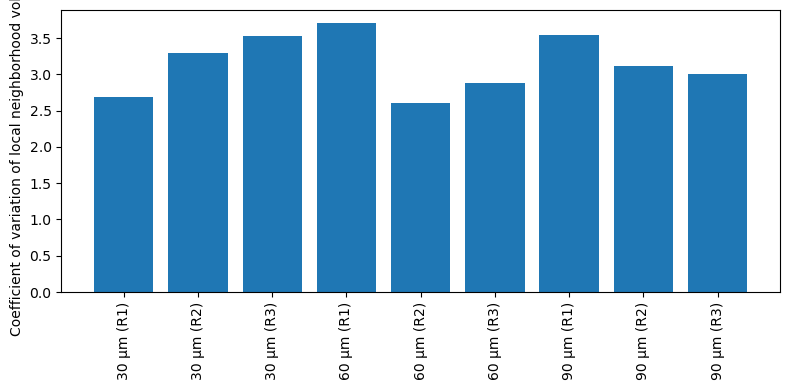

In [8]:
# ─── 6) UMAP ASSUMPTION CHECK + SUPPLEMENTARY FIGURE ────────────────────────
def check_umap_assumptions(X, df, group_col="source_file", k=30):
    results = []
    for group, idx in df.groupby(group_col).groups.items():
        Xg = X.loc[idx].values
        if Xg.shape[0] <= k:
            continue
        nbrs = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(Xg)
        distances, indices = nbrs.kneighbors(Xg)
        knn_graph = nbrs.kneighbors_graph(Xg, mode="connectivity")
        n_components, labels = connected_components(knn_graph, directed=False)
        component_sizes = np.bincount(labels)
        dominant_fraction = component_sizes.max() / Xg.shape[0]
        volumes = []
        for neigh_idx in indices:
            pts = Xg[neigh_idx]
            cov = np.cov(pts, rowvar=False) + np.eye(pts.shape[1]) * 1e-12
            eigvals = np.linalg.eigvalsh(cov)
            volume = np.sqrt(np.prod(np.clip(eigvals, 1e-12, None)))
            volumes.append(volume)
        volumes = np.array(volumes)
        meta_row = df.loc[idx[0]]
        results.append({
            group_col: group,
            "__size": meta_row.get("__size"),
            "__mac": meta_row.get("__mac"),
            "__rep": meta_row.get("__rep"),
            "n_points": Xg.shape[0],
            "n_components": n_components,
            "dominant_component_fraction": dominant_fraction,
            "volume_cv": np.std(volumes) / np.mean(volumes)
        })
    return pd.DataFrame(results)

SAVE_KW = dict(dpi=300, bbox_inches="tight")

def plot_qc(qc_results, outdir, tag):
    """x-axis label: '{size} µm | -Mac/+Mac (R{n})' for B cells -- grouped by
    size then Mac status (so -Mac and +Mac replicates are never interleaved),
    with replicates renumbered R1, R2, ... in order within each group, since
    the original replicate numbers aren't always contiguous within a group.
    Macrophages (no __mac column) get '{size} µm (R{n})', grouped/renumbered
    by size alone."""
    outdir.mkdir(exist_ok=True, parents=True)
    has_mac = qc_results["__mac"].notna().any()
    group_cols = ["__size", "__mac"] if has_mac else ["__size"]

    qc_plot = qc_results.sort_values(group_cols + ["__rep", "source_file"]).copy()
    qc_plot["__rep_n"] = qc_plot.groupby(group_cols).cumcount() + 1

    mac_display = {"N": "-Mac", "Y": "+Mac"}
    def _qc_label(row):
        mac = row.get("__mac")
        if pd.notna(mac):
            return f"{row['__size']} µm | {mac_display.get(mac, mac)} (R{row['__rep_n']})"
        return f"{row['__size']} µm (R{row['__rep_n']})"

    qc_plot["__label"] = qc_plot.apply(_qc_label, axis=1)

    fig1 = plt.figure(figsize=(8, 4))
    plt.bar(qc_plot["__label"], qc_plot["dominant_component_fraction"])
    plt.axhline(0.90, linestyle="--", linewidth=1)
    plt.ylabel("Dominant connected component fraction")
    plt.xticks(rotation=90)
    plt.tight_layout()
    fig1.savefig(outdir / f"{tag}_umap_qc_connectivity.png", **SAVE_KW)
    fig1.savefig(outdir / f"{tag}_umap_qc_connectivity.pdf", bbox_inches="tight")
    plt.show()

    fig2 = plt.figure(figsize=(8, 4))
    plt.bar(qc_plot["__label"], qc_plot["volume_cv"])
    plt.ylabel("Coefficient of variation of local neighborhood volume")
    plt.xticks(rotation=90)
    plt.tight_layout()
    fig2.savefig(outdir / f"{tag}_umap_qc_density.png", **SAVE_KW)
    fig2.savefig(outdir / f"{tag}_umap_qc_density.pdf", bbox_inches="tight")
    plt.show()

print("=== Macrophages UMAP QC ===")
qc_macro = check_umap_assumptions(X_macro, df_macro, k=UMAP_PARAMS_MACRO["n_neighbors"])
display(qc_macro)
plot_qc(qc_macro, MACRO_OUTDIR, "macro")


## 7. UMAP -> HDBSCAN -- Macrophages
An independent UMAP + HDBSCAN run on the 9 macrophage replicates.

In [9]:
# ─── 7) UMAP → HDBSCAN — MACROPHAGES ────────────────────────────────────────
def _scale_umap_hdbscan(X_df, umap_params, hdb_params):
    """Input: pandas DataFrame (rows=samples, cols=features), already cleaned/aligned.
       Output: (U, labels) aligned to X_df.index
    """
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X_df.values)
    um = umap.UMAP(**umap_params)
    U = um.fit_transform(Xz)
    clusterer = hdbscan.HDBSCAN(**hdb_params)
    labels = clusterer.fit_predict(U)
    return U, labels

U_macro, labels_macro = _scale_umap_hdbscan(X_macro, UMAP_PARAMS_MACRO, HDBSCAN_PARAMS_MACRO)

df_macro.loc[X_macro.index, "UMAP1"] = U_macro[:, 0]
df_macro.loc[X_macro.index, "UMAP2"] = U_macro[:, 1]
df_macro.loc[X_macro.index, "cluster"] = labels_macro
df_macro["cluster"] = df_macro["cluster"].astype("Int64")

macro_emb = pd.DataFrame({
    "UMAP1": U_macro[:, 0], "UMAP2": U_macro[:, 1], "cluster": labels_macro,
    "condition": df_macro.loc[X_macro.index, "condition"].values,
    "size_um": df_macro.loc[X_macro.index, "__size"].values,
    "replicate": df_macro.loc[X_macro.index, "__rep"].values,
    "source_file": df_macro.loc[X_macro.index, "source_file"].values,
}, index=X_macro.index)

print("MACROPHAGE clusters (incl. noise=-1):", sorted(pd.unique(labels_macro)))
print(macro_emb["cluster"].value_counts().sort_index())
print("\nCluster composition by well size (%):")
print(pd.crosstab(macro_emb["cluster"], macro_emb["size_um"], normalize="index").mul(100).round(1))


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



MACROPHAGE clusters (incl. noise=-1): [np.int64(-1), np.int64(0), np.int64(1)]
cluster
-1       64
 0      708
 1    12683
Name: count, dtype: int64

Cluster composition by well size (%):
size_um    30    60    90
cluster                  
-1       39.1  29.7  31.2
 0       45.5  36.3  18.2
 1       55.7  26.7  17.7


## 8. Scatterplots (Matplotlib)
UMAP embedding colored by HDBSCAN cluster and by well size.

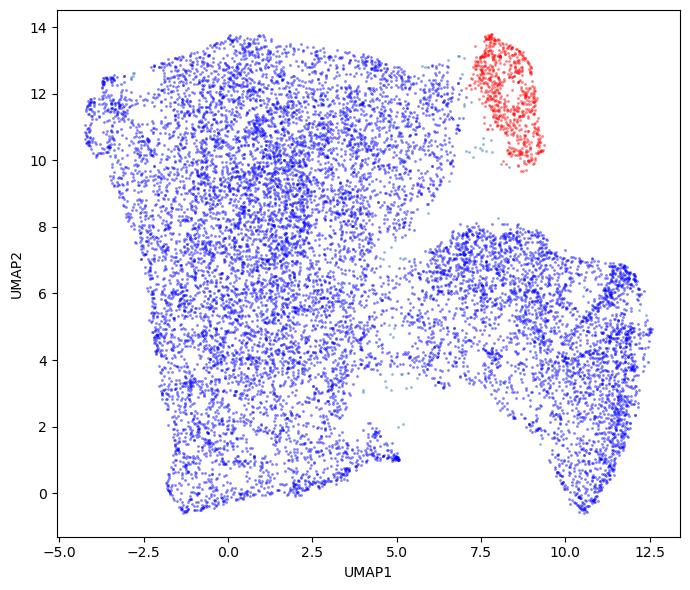

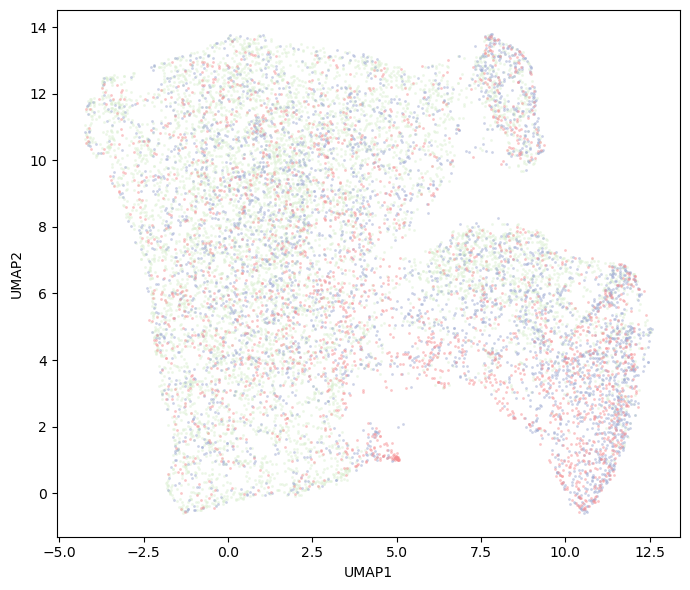

In [10]:
# ─── 8) SCATTERPLOTS (MATPLOTLIB) ────────────────────────────────────────────
POINT_SIZE = 4
POINT_ALPHA = 0.5
FALLBACK_CMAP = plt.get_cmap("tab10")
CLUSTER_COLORS = {"0": "red", "1": "blue"}
SAVE_KW = dict(dpi=300, bbox_inches="tight")

def get_cluster_color(label, i):
    return CLUSTER_COLORS.get(label, FALLBACK_CMAP(i % FALLBACK_CMAP.N))

def _display(value, mapper):
    """Turn a raw data value into a display string. `mapper` may be None
    (use the value as-is), a dict, a callable, or a "{}"-style format string."""
    if mapper is None:
        return str(value)
    if callable(mapper):
        return mapper(value)
    if isinstance(mapper, dict):
        return mapper.get(value, str(value))
    return mapper.format(value)

def format_condition_display(cond):
    """Turn a raw condition string ('30um|N' or '30um') into a display label
    ('30 µm | -Mac' or '30 µm')."""
    s = re.sub(r"(\d+)\s*um", r"\1 µm", cond)
    return s.replace("|Y", " | +Mac").replace("|N", " | -Mac")

def save_legend(handles, outdir, filename_stem, title=None, ncol=1):
    """Save a legend as its own tightly-cropped PNG/PDF, separate from the plot
    it came from -- for figures assembled/laid out later (e.g. in Illustrator)."""
    outdir.mkdir(exist_ok=True, parents=True)
    fig_leg = plt.figure(figsize=(4, 4))
    legend = fig_leg.legend(handles=handles, title=title, loc="center", frameon=False, ncol=ncol)
    fig_leg.canvas.draw()
    bbox = legend.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())
    fig_leg.savefig(outdir / f"{filename_stem}.png", dpi=300, bbox_inches=bbox, pad_inches=0.05)
    fig_leg.savefig(outdir / f"{filename_stem}.pdf", bbox_inches=bbox, pad_inches=0.05)
    plt.close(fig_leg)

def plot_umap_by_cluster(emb_df, outdir, filename_stem):
    outdir.mkdir(exist_ok=True, parents=True)
    clusters = emb_df["cluster"].astype(str)
    cluster_labels = np.sort(clusters.unique())
    fig, ax = plt.subplots(figsize=(7, 6))
    for i, lab in enumerate(cluster_labels):
        m = (clusters == lab).to_numpy()
        ax.scatter(emb_df.loc[m, "UMAP1"], emb_df.loc[m, "UMAP2"], s=POINT_SIZE, alpha=POINT_ALPHA,
                   c=[get_cluster_color(lab, i)], linewidths=0)
    handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=get_cluster_color(lab, i),
                       markeredgewidth=0, markersize=8, label=f"Cluster {lab}")
               for i, lab in enumerate(cluster_labels)]
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    fig.tight_layout()
    fig.savefig(outdir / f"{filename_stem}.png", **SAVE_KW)
    fig.savefig(outdir / f"{filename_stem}.pdf", bbox_inches="tight")
    plt.show()
    save_legend(handles, outdir, f"{filename_stem}_legend", title="Cluster")

def plot_umap_by_label(emb_df, label_col, outdir, filename_stem, palette=None, label_map=None):
    outdir.mkdir(exist_ok=True, parents=True)
    labs = emb_df[label_col].astype(str)
    lab_values = np.sort(labs.unique())
    cmap = plt.get_cmap("tab10")
    colors = palette or {lab: cmap(i % cmap.N) for i, lab in enumerate(lab_values)}
    fig, ax = plt.subplots(figsize=(7, 6))
    for lab in lab_values:
        m = (labs == lab).to_numpy()
        ax.scatter(emb_df.loc[m, "UMAP1"], emb_df.loc[m, "UMAP2"], s=POINT_SIZE, alpha=POINT_ALPHA,
                   c=[colors[lab]], linewidths=0)
    handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=colors[lab],
                       markeredgewidth=0, markersize=8, label=_display(lab, label_map))
               for lab in lab_values]
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    fig.tight_layout()
    fig.savefig(outdir / f"{filename_stem}.png", **SAVE_KW)
    fig.savefig(outdir / f"{filename_stem}.pdf", bbox_inches="tight")
    plt.show()
    save_legend(handles, outdir, f"{filename_stem}_legend", title=label_col)

# Fixed color mapping by well size, keyed to match the "condition" column's
# actual format ("30um", "60um", "90um").
SIZE_COLOR_MAP = {"30": "#DAEFD1", "60": "#9CA9D2", "90": "#F68F92"}
MACRO_CONDITION_PALETTE = {f"{k}um": v for k, v in SIZE_COLOR_MAP.items()}

plot_umap_by_cluster(macro_emb, MACRO_OUTDIR, "macro_umap_by_cluster")
plot_umap_by_label(macro_emb, "condition", MACRO_OUTDIR, "macro_umap_by_condition",
                    palette=MACRO_CONDITION_PALETTE, label_map=format_condition_display)


## 8b. Faceted scatterplots by well size
UMAP embedding colored by HDBSCAN cluster, faceted into the 3 well-size conditions.

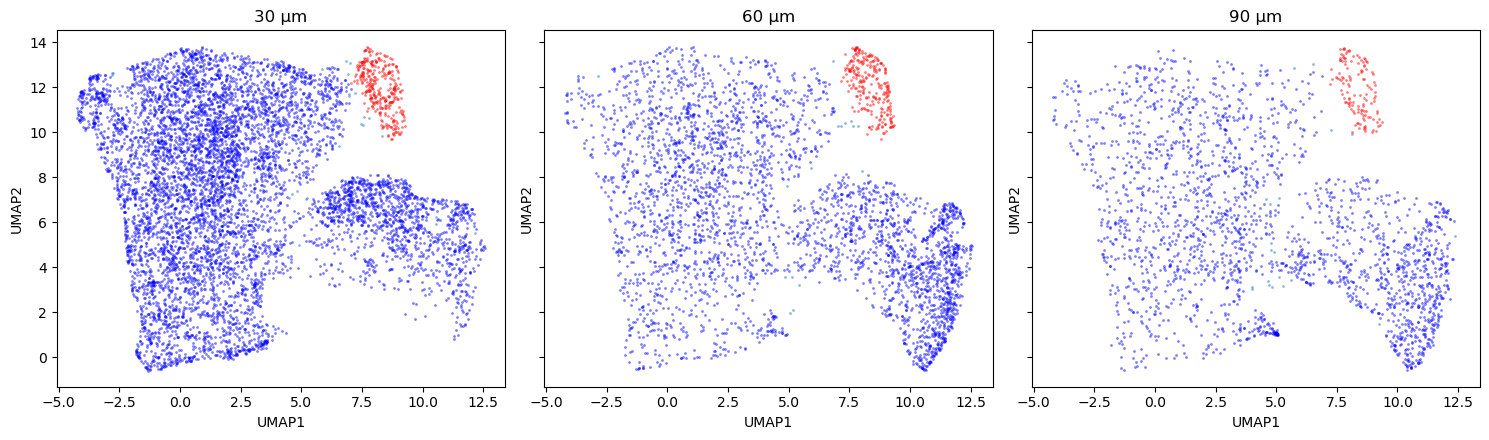

In [11]:
# ─── 8b) FACETED SCATTERPLOTS BY WELL SIZE ───────────────────────────────────
def _draw_condition_panel(ax, emb_df, clusters, cluster_labels, cond):
    """Draw one condition's points (colored by cluster) onto `ax`. Returns False
    (and blanks the axis) if this condition has no data."""
    mcond = (emb_df["condition"] == cond).to_numpy()
    if not np.any(mcond):
        ax.axis("off")
        return False
    for i, lab in enumerate(cluster_labels):
        m = mcond & (clusters == lab).to_numpy()
        if not np.any(m):
            continue
        ax.scatter(emb_df.loc[m, "UMAP1"], emb_df.loc[m, "UMAP2"], s=POINT_SIZE, alpha=POINT_ALPHA,
                   c=[get_cluster_color(lab, i)], linewidths=0)
    ax.set_title(format_condition_display(cond))
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    return True

def plot_umap_by_cluster_faceted(emb_df, condition_order, outdir, filename_stem, ncols=3):
    """Saves the combined multi-panel overview figure, its legend, AND each
    condition's panel as its own standalone file (for laying out separately,
    e.g. in Illustrator)."""
    outdir.mkdir(exist_ok=True, parents=True)
    clusters = emb_df["cluster"].astype(str)
    cluster_labels = np.sort(clusters.unique())

    n = len(condition_order)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4.5 * nrows),
                              sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    for idx in range(nrows * ncols):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        if idx >= n:
            ax.axis("off")
            continue
        _draw_condition_panel(ax, emb_df, clusters, cluster_labels, condition_order[idx])

    handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=get_cluster_color(lab, i),
                       markeredgewidth=0, markersize=8, label=f"Cluster {lab}")
               for i, lab in enumerate(cluster_labels)]
    fig.tight_layout()
    fig.savefig(outdir / f"{filename_stem}.png", **SAVE_KW)
    fig.savefig(outdir / f"{filename_stem}.pdf", bbox_inches="tight")
    plt.show()
    save_legend(handles, outdir, f"{filename_stem}_legend", title="Cluster")

    for cond in condition_order:
        slug = re.sub(r"[^\w\-]+", "_", cond).strip("_")
        fig_i, ax_i = plt.subplots(figsize=(5, 4.5))
        drawn = _draw_condition_panel(ax_i, emb_df, clusters, cluster_labels, cond)
        if drawn:
            fig_i.tight_layout()
            fig_i.savefig(outdir / f"{filename_stem}_{slug}.png", **SAVE_KW)
            fig_i.savefig(outdir / f"{filename_stem}_{slug}.pdf", bbox_inches="tight")
        plt.close(fig_i)

plot_umap_by_cluster_faceted(
    macro_emb,
    condition_order=["30um", "60um", "90um"],
    outdir=MACRO_OUTDIR,
    filename_stem="macro_umap_by_cluster_faceted",
    ncols=3
)


## 9. Cluster composition by well size
The % of macrophage tracks in each cluster, by well size. Uses the same
`plot_cluster_composition` helper as the B cell notebook's Section 9, just with a single panel
(no macrophage-presence split here) and bars grouped by well size instead.

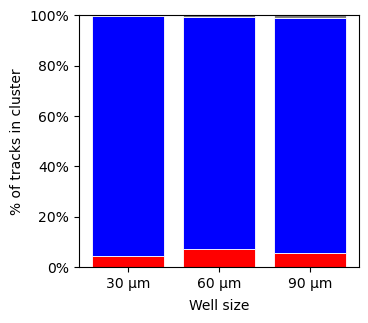

In [12]:
# ─── 9) CLUSTER COMPOSITION BAR CHART ────────────────────────────────────────
def build_cluster_colors(emb_df):
    """Cluster 0 = red, Cluster 1 = blue, noise (-1) = grey; any other cluster
    gets a color from Plotly's qualitative palette."""
    cluster_labels = sorted(emb_df["cluster"].astype(str).unique())
    plotly_palette = px.colors.qualitative.Plotly
    colors = {cl: plotly_palette[i % len(plotly_palette)] for i, cl in enumerate(cluster_labels)}
    colors["0"] = "red"
    colors["1"] = "blue"
    colors["-1"] = "grey"
    return colors

DEFAULT_CLUSTER_COLOR = "grey"

def plot_cluster_composition(emb_df, bar_col, outdir, filename_stem, panel_col=None,
                              panel_order=None, bar_order=None, panel_label_fmt="{}",
                              bar_label_fmt="{}", xlabel="Condition", figsize=None,
                              show_legend=True):
    """Stacked bar chart of the % of tracks in each cluster. `bar_col` sets the
    x-axis categories within a panel; `panel_col` (optional) splits the figure
    into side-by-side panels, e.g. one per well size. `panel_label_fmt` /
    `bar_label_fmt` may be a "{}"-style format string, a dict, or a callable."""
    outdir.mkdir(exist_ok=True, parents=True)
    df = emb_df.copy()
    df["cluster_str"] = df["cluster"].astype(str)
    cluster_colors = build_cluster_colors(df)

    bar_labels = bar_order or sorted(df[bar_col].unique())
    panels = (panel_order or sorted(df[panel_col].unique())) if panel_col else [None]

    if panel_col:
        counts = pd.crosstab([df[panel_col], df[bar_col]], df["cluster_str"])
    else:
        counts = pd.crosstab(df[bar_col], df["cluster_str"])
    props = counts.div(counts.sum(axis=1), axis=0).fillna(0)

    cluster_order = list(props.columns)
    if "-1" in cluster_order:
        cluster_order = [c for c in cluster_order if c != "-1"] + ["-1"]
    props = props[cluster_order]

    if figsize is None:
        figsize = (180 / 25.4, 80 / 25.4)
    fig = plt.figure(figsize=figsize)
    axes = fig.subplots(1, len(panels), sharey=True)
    axes = np.atleast_1d(axes)

    x = np.arange(len(bar_labels))
    for ax, panel in zip(axes, panels):
        if panel_col:
            idx = pd.MultiIndex.from_product([[panel], bar_labels])
            sub = props.reindex(idx).fillna(0)
        else:
            sub = props.reindex(bar_labels).fillna(0)

        bottom = np.zeros(len(bar_labels))
        for cl in cluster_order:
            vals = sub[cl].values
            ax.bar(x, vals, bottom=bottom, label=f"Cluster {cl}",
                   color=cluster_colors.get(cl, DEFAULT_CLUSTER_COLOR),
                   edgecolor="white", linewidth=0.6)
            bottom += vals

        if panel is not None:
            ax.set_title(_display(panel, panel_label_fmt), pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels([_display(b, bar_label_fmt) for b in bar_labels])
        ax.set_ylim(0, 1.0)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    axes[0].set_ylabel("% of tracks in cluster")
    right_margin = 0.80 if show_legend else 0.95
    left_margin = 14.4 / (figsize[0] * 25.4)  # keep the y-axis label gutter a constant absolute width
    fig.subplots_adjust(left=left_margin, right=right_margin, top=0.86, bottom=0.15, wspace=0.25)
    fig.text((left_margin + right_margin) / 2, 0.04, xlabel, ha="center", va="center")

    if show_legend:
        handles, labels = axes[-1].get_legend_handles_labels()
        seen = set(); handles2 = []; labels2 = []
        for h, l in zip(handles, labels):
            if l not in seen:
                handles2.append(h); labels2.append(l); seen.add(l)
        fig.legend(handles2, labels2, title="Cluster", loc="center left", bbox_to_anchor=(0.82, 0.5), frameon=False)

    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42
    fig.savefig(outdir / f"{filename_stem}.pdf")
    fig.savefig(outdir / f"{filename_stem}.png", dpi=300)
    plt.show()

macro_plot_df = macro_emb.copy()
macro_plot_df["size_um"] = macro_plot_df["size_um"].astype(int)

plot_cluster_composition(
    macro_plot_df,
    bar_col="size_um", bar_order=[30, 60, 90], bar_label_fmt="{} µm",
    outdir=MACRO_OUTDIR, filename_stem="macro_cluster_composition",
    xlabel="Well size", figsize=(90 / 25.4, 90 / 25.4), show_legend=False
)


## 10. Random Forest + SHAP
Trains a Random Forest to predict the macrophage cluster label from z-scored features,
reports CV accuracy, and computes SHAP per cluster. Figures are saved to this run's output
folder under `Final Analysis Outputs/Macrophages Updated`.


Macrophages
Rows: 13455 | Non-noise: 13391 | Noise: 64
Clusters (non-noise): [np.int64(0), np.int64(1)]
0      708
1    12683


[CV] RF accuracy: 1.000 +/- 0.000 (n_splits=5)


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


,feature,importance
0,NUMBER_SPOTS,0.286325
1,NUMBER_SPLITS,0.252335
2,TRACK_DURATION,0.203449
3,TOTAL_DISTANCE_TRAVELED,0.121578
4,TRACK_DISPLACEMENT,0.056347
5,TRACK_MEDIAN_SPEED,0.043186
6,CONFINEMENT_RATIO,0.029645
7,MEAN_DIRECTIONAL_CHANGE_RATE,0.007134


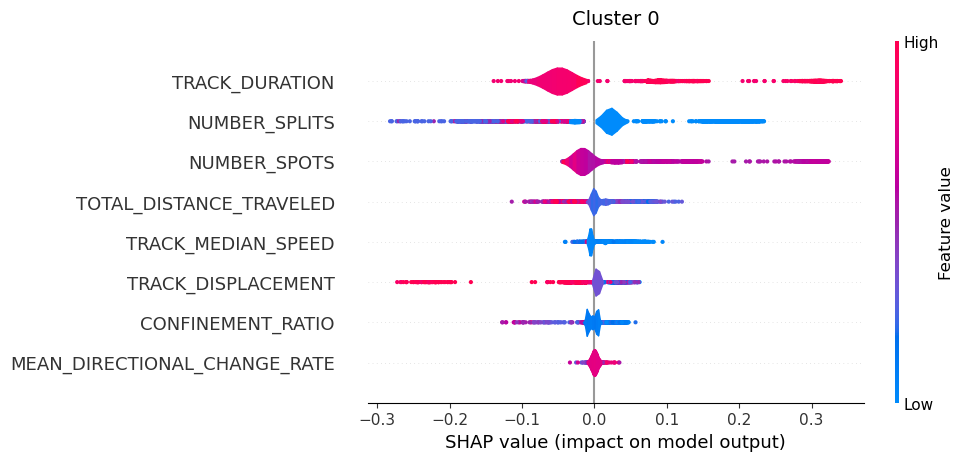

,cluster,feature,mean_abs_SHAP
0,0,TRACK_DURATION,0.067965
1,0,NUMBER_SPLITS,0.043926
2,0,NUMBER_SPOTS,0.035763
3,0,TOTAL_DISTANCE_TRAVELED,0.013017
4,0,TRACK_MEDIAN_SPEED,0.008346
5,0,TRACK_DISPLACEMENT,0.007669
6,0,CONFINEMENT_RATIO,0.007056
7,0,MEAN_DIRECTIONAL_CHANGE_RATE,0.001296


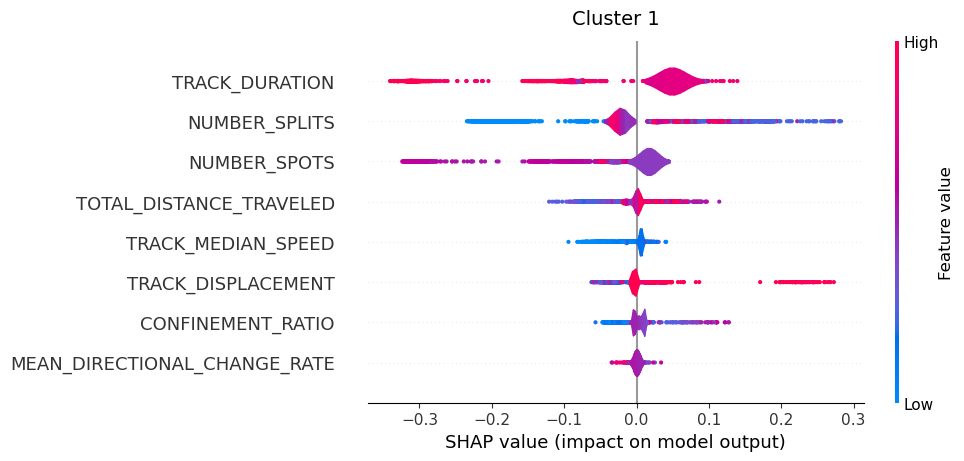

,cluster,feature,mean_abs_SHAP
0,1,TRACK_DURATION,0.067965
1,1,NUMBER_SPLITS,0.043926
2,1,NUMBER_SPOTS,0.035763
3,1,TOTAL_DISTANCE_TRAVELED,0.013017
4,1,TRACK_MEDIAN_SPEED,0.008346
5,1,TRACK_DISPLACEMENT,0.007669
6,1,CONFINEMENT_RATIO,0.007056
7,1,MEAN_DIRECTIONAL_CHANGE_RATE,0.001296


,cluster,feature,mean_abs_SHAP
0,0,TRACK_DURATION,0.067965
1,0,NUMBER_SPLITS,0.043926
2,0,NUMBER_SPOTS,0.035763
3,0,TOTAL_DISTANCE_TRAVELED,0.013017
4,0,TRACK_MEDIAN_SPEED,0.008346
5,0,TRACK_DISPLACEMENT,0.007669
6,0,CONFINEMENT_RATIO,0.007056
7,0,MEAN_DIRECTIONAL_CHANGE_RATE,0.001296
8,1,TRACK_DURATION,0.067965
9,1,NUMBER_SPLITS,0.043926



Saved PNGs to: ./Final Analysis Outputs/Macrophages Updated/20260813


In [13]:
# ─── 10) Random Forest + SHAP -- MACROPHAGES ────────────────────────────────
def _safe(s: str) -> str:
    return re.sub(r"[^\w\-]+", "_", str(s)).strip("_")[:160]

def save_df_as_png(df, filepath, max_rows=25, fontsize=10):
    df_show = df.head(max_rows).copy()
    fig_h = max(2.0, 0.35 * len(df_show) + 1.2)
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    tbl = ax.table(cellText=df_show.values, colLabels=df_show.columns, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.25)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def _coi_explanation_for_class(shap_values, coi_idx):
    if hasattr(shap_values, "values"):
        if shap_values.values.ndim == 3:
            return shap.Explanation(
                values=shap_values.values[:, :, coi_idx],
                base_values=np.array(shap_values.base_values)[:, coi_idx],
                data=shap_values.data,
                feature_names=shap_values.feature_names
            )
        else:
            return shap_values
    else:
        return shap_values[coi_idx]

def explain_clusters_shap_and_export(model, X_eval, y_clusters, feat_names, outdir, run_tag, max_display=20):
    if len(np.unique(y_clusters)) < 2:
        print("[WARN] < 2 classes in y_clusters; SHAP per-class view not meaningful.")
        return None

    X_for_shap = pd.DataFrame(X_eval, columns=feat_names)
    le = LabelEncoder()
    le.fit_transform(y_clusters)
    raw_classes = sorted(np.unique(y_clusters))

    outdir.mkdir(exist_ok=True, parents=True)
    run_tag = _safe(run_tag)

    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_for_shap)

    tables = []
    for COI in raw_classes:
        encoded_label = le.transform([COI])[0]
        coi_idx_arr = np.where(model.classes_ == encoded_label)[0]
        if len(coi_idx_arr) == 0:
            continue
        coi_idx = coi_idx_arr[0]
        coi_shap = _coi_explanation_for_class(shap_values, coi_idx)
        vals = getattr(coi_shap, "values", coi_shap)

        plt.figure(figsize=(10, 6))
        try:
            shap.plots.violin(coi_shap, max_display=max_display, show=False)
        except Exception:
            shap.summary_plot(vals, X_eval, feature_names=feat_names, plot_type="violin",
                               max_display=max_display, show=False)
        plt.title(f"Cluster {COI}", fontsize=14, pad=12)
        plt.savefig(outdir / f"{run_tag}_cluster_{COI}_SHAP_violin.png", dpi=300, bbox_inches="tight")
        plt.show()

        mean_abs = np.abs(vals).mean(axis=0)
        df_imp = (pd.DataFrame({"feature": feat_names, "mean_abs_SHAP": mean_abs})
                    .sort_values("mean_abs_SHAP", ascending=False).reset_index(drop=True))
        df_imp.insert(0, "cluster", COI)
        tables.append(df_imp)
        save_df_as_png(df_imp, outdir / f"{run_tag}_cluster_{COI}_SHAP_table.png", max_rows=max_display)
        display(df_imp.head(max_display))

    if tables:
        all_tbl = pd.concat(tables, ignore_index=True)
        save_df_as_png(all_tbl, outdir / f"{run_tag}_SHAP_all_clusters_table.png", max_rows=40)
        display(all_tbl.head(40))
        return all_tbl
    return None

def run_rf_shap(X_df, y_labels, feat_cols, title, outdir):
    """RF + SHAP for predicting cluster label from z-scored features."""
    outdir.mkdir(exist_ok=True, parents=True)
    title_safe = _safe(title)

    mask = (y_labels != -1)
    X_keep = X_df.loc[mask].copy()
    y_keep = y_labels[mask]

    print("\n" + "=" * 100)
    print(title)
    print(f"Rows: {len(y_labels)} | Non-noise: {len(y_keep)} | Noise: {len(y_labels) - len(y_keep)}")
    print("Clusters (non-noise):", sorted(pd.unique(y_keep)))
    print(pd.Series(y_keep).value_counts().sort_index().to_string())
    print("=" * 100)

    if len(np.unique(y_keep)) < 2:
        print("[WARN] < 2 non-noise clusters; RF classification not meaningful.")
        return None, None, None

    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X_keep.values)

    rf = RandomForestClassifier(**RF_PARAMS)
    n_splits = 5 if len(y_keep) >= 50 and all((y_keep == k).sum() >= 5 for k in np.unique(y_keep)) else 3
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(rf, Xz, y_keep, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"[CV] RF accuracy: {scores.mean():.3f} +/- {scores.std():.3f} (n_splits={n_splits})")

    rf.fit(Xz, y_keep)
    fi = (pd.DataFrame({"feature": feat_cols, "importance": rf.feature_importances_})
            .sort_values("importance", ascending=False).reset_index(drop=True))

    fig_b = px.bar(fi, x="feature", y="importance")
    fig_b.update_layout(xaxis_tickangle=-30)
    fig_b.show()
    fig_b.write_image(outdir / f"{title_safe}_RF_feature_importance.png")
    save_df_as_png(fi, outdir / f"{title_safe}_RF_feature_importance_table.png", max_rows=25)
    display(fi.head(25))

    shap_tbl = explain_clusters_shap_and_export(rf, Xz, y_keep, feat_cols, outdir, title_safe)
    return rf, fi, shap_tbl

rf_macro, fi_macro, shap_macro = run_rf_shap(
    X_df=X_macro, y_labels=labels_macro, feat_cols=feat_cols,
    title="Macrophages", outdir=MACRO_OUTDIR
)
print(f"\nSaved PNGs to: ./{MACRO_OUTDIR.relative_to(BASE_DIR)}")
